# 1: Importação de Bibliotecas e Carga de Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Carregar o dataset preparado no Notebook 01
df = pd.read_pickle('dados_voos_limpos.pkl')

print(f"Dados carregados: {df.shape[0]} linhas.")

Dados carregados: 5714008 linhas.


# 2: Seleção de Features (Variáveis Preditoras)

In [3]:
# Selecionando colunas que temos antes do voo acontecer
features = ['MONTH', 'DAY_OF_WEEK', 'AIRLINE_CODE', 'ORIGIN_AIRPORT', 
            'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DISTANCE']

X = df[features]
y = df['IS_DELAYED']

# Para que o processamento seja rápido durante o desenvolvimento, 
X_sample = X.sample(500000, random_state=42)
y_sample = y.loc[X_sample.index]

print("Features selecionadas e amostra preparada.")

Features selecionadas e amostra preparada.


# 3: Pré-processamento (Label Encoding)

Os algoritmos não entendem os códigos de texto (como 'JFK' ou 'LAX'). Vamos transformá-los em números.

In [4]:
# Transformar as colunas de texto (IATA Codes) em números
le = LabelEncoder()

# Criamos uma cópia para não dar aviso de SettingWithCopy
X_proc = X_sample.copy()

for col in ['AIRLINE_CODE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']:
    # Convertendo para string para evitar erro caso haja números misturados
    X_proc[col] = le.fit_transform(X_proc[col].astype(str))

print("Codificação de texto para número concluída.")

Codificação de texto para número concluída.


# 4: Divisão em Treino e Teste

Vamos separar 20% dos dados para testar o modelo após o treinamento

In [5]:
# Dividindo os dados de treino e teste

X_train, X_test, y_train, y_test = train_test_split(X_proc, y_sample, test_size=0.2, random_state=42)

# Normalização: Importante para a Regressão Logística performar bem
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Treino: 400000 amostras
Teste: 100000 amostras


# 5: Modelo 1 - Regressão Logística (Baseline)

In [6]:
print("Treinando Regressão Logística...")
model_lr = LogisticRegression()
model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)

print("\n--- Resultado: Regressão Logística ---")
print(classification_report(y_test, y_pred_lr))

Treinando Regressão Logística...

--- Resultado: Regressão Logística ---
              precision    recall  f1-score   support

           0       0.82      1.00      0.90     82103
           1       0.00      0.00      0.00     17897

    accuracy                           0.82    100000
   macro avg       0.41      0.50      0.45    100000
weighted avg       0.67      0.82      0.74    100000



c:\Users\hcapristano\Documents\FIAP\FIAP modulo 3\Tech Challenge 3\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hcapristano\Documents\FIAP\FIAP modulo 3\Tech Challenge 3\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hcapristano\Documents\FIAP\FIAP modulo 3\Tech Challenge 3\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

# 6: Modelo 2 - Random Forest (Mais complexo)

O Random Forest costuma ser muito melhor para capturar padrões não-lineares (como o fato de atrasos subirem à noite).

In [7]:
print("Treinando Random Forest (pode demorar 1-2 minutos)...")
model_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_rf.fit(X_train, y_train) # Random Forest não precisa obrigatoriamente dos dados escalonados

y_pred_rf = model_rf.predict(X_test)

print("\n--- Resultado: Random Forest ---")
print(classification_report(y_test, y_pred_rf))

Treinando Random Forest (pode demorar 1-2 minutos)...

--- Resultado: Random Forest ---
              precision    recall  f1-score   support

           0       0.82      1.00      0.90     82103
           1       1.00      0.00      0.00     17897

    accuracy                           0.82    100000
   macro avg       0.91      0.50      0.45    100000
weighted avg       0.85      0.82      0.74    100000



# 7: Melhorando o modelo Random Forest

Vamos dizer ao modelo que errar um atraso é "mais caro" do que errar um voo pontual.

In [8]:
print("Treinando Random Forest (pode demorar 1-2 minutos)...")
model_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
model_rf.fit(X_train, y_train) # Random Forest não precisa obrigatoriamente dos dados escalonados

y_pred_rf = model_rf.predict(X_test)

print("\n--- Resultado: Random Forest ---")
print(classification_report(y_test, y_pred_rf))

Treinando Random Forest (pode demorar 1-2 minutos)...

--- Resultado: Random Forest ---
              precision    recall  f1-score   support

           0       0.88      0.60      0.71     82103
           1       0.25      0.63      0.36     17897

    accuracy                           0.60    100000
   macro avg       0.57      0.61      0.54    100000
weighted avg       0.77      0.60      0.65    100000



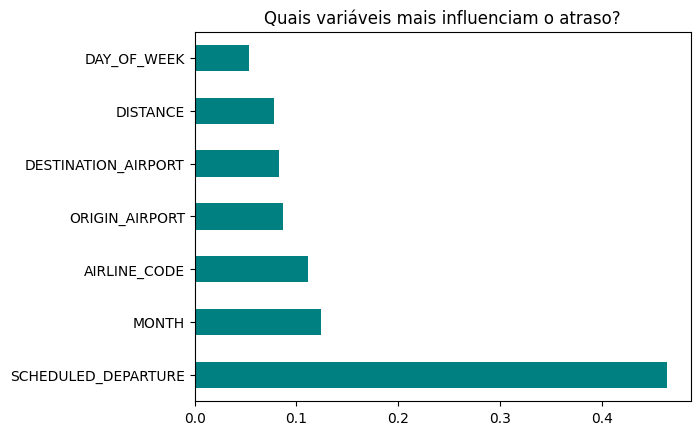

In [9]:
# Verificando a importância das colunas
importancias = pd.Series(model_rf.feature_importances_, index=features)
importancias.sort_values(ascending=False).plot(kind='barh', color='teal')
plt.title('Quais variáveis mais influenciam o atraso?')
plt.show()